# Linear Models

Check the performance of SVM and logistic regression on our engineered data sets before moving to more complex models.

In [41]:
%reload_ext autoreload
%autoreload 2
import sys, os
import pandas as pd
import warnings
import numpy as np
from sklearn.model_selection import train_test_split
from pathlib import Path

warnings.filterwarnings('ignore')
DATA_DIR = Path('../src/shared_util/data')
METRICS_DIR = DATA_DIR
CSV_PATH = METRICS_DIR / 'metrics.csv'
LOG = True



from shared_util.metrics import metrics_db
from shared_util.dataio import load_csv



if LOG:
    metrics_db.read_in(CSV_PATH)

METRICS_DB_ID = 0 # update this to not overwrite previous metrics for these models
METRIC_NOTES = "first pass" # global metric notes for this run


In [42]:
df = load_csv('linear_frame')

In [43]:
X_train, X_, y_train, y_ = train_test_split(df.drop(columns=['target']), df['target'], test_size=0.3, stratify=df['target'])
X_validate, X_test, y_validate, y_test = train_test_split(df.drop(columns=['target']), df['target'], test_size=0.5, stratify=df['target'])

In [44]:
from sklearn.model_selection import StratifiedKFold

def make_cv():
    return StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
    )



## Baseline Logistic Regression

In [45]:
from sklearn.linear_model import SGDClassifier
from imblearn.under_sampling import RandomUnderSampler
from sklearn.preprocessing import StandardScaler

from shared_util.baseline import get_baseline_score
from imblearn.pipeline import Pipeline


print('Baseline SGD Classifier')

roc_auc = get_baseline_score(
    SGDClassifier(random_state=42),
    RandomUnderSampler(random_state=42),
    X_train,
    y_train,
    scaler=StandardScaler()
    )


if LOG:
    metrics_db.log_metric(
        metric_id=METRICS_DB_ID,
        model='sgd_base_undsampl',
        pipeline_notes='under_sample',
        notes=METRIC_NOTES,
        roc_auc=roc_auc
    )



Baseline SGD Classifier
roc_auc_score score per fold:  [0.56269161 0.58904717 0.55457757 0.5846892  0.58380726 0.57658842
 0.57736509 0.57680186 0.58040431 0.57878931]
mean roc_auc_score score:  0.5764761793636565
logged row: (0, sgd_base_undsampl)


In [46]:
# try SMOTE
from imblearn.over_sampling import SMOTE

print('Baseline ROC_AUC using SMOTE')

roc_auc = get_baseline_score(
    SGDClassifier(random_state=42),
    SMOTE(random_state=42),
    X_train,
    y_train,
    scaler=StandardScaler()
    )

if LOG:
    metrics_db.log_metric(
        metric_id=METRICS_DB_ID,
        model='sgd_base_smote',
        pipeline_notes='SMOTE',
        notes=METRIC_NOTES,
        roc_auc=roc_auc
    )


Baseline ROC_AUC using SMOTE
roc_auc_score score per fold:  [0.49983902 0.50703427 0.49942159 0.49983902 0.49991951 0.5055649
 0.50219693 0.50054843 0.51092331 0.4999195 ]
mean roc_auc_score score:  0.5025206478713302
logged row: (0, sgd_base_smote)


Interestingly, baseline SGD using under sampling performed worse than baseline random forest using the same, but when using SMOTE, the linear model slightly outperformed the baseline random forest model.

In [47]:
def make_base_sgd(use_smote=False):
    return Pipeline([
        ('sampler',SMOTE(random_state=42) if use_smote else RandomUnderSampler(random_state=42)),
        ('scaler', StandardScaler()),
        ('model', SGDClassifier(random_state=42))
    ])

In [48]:
# hyperparam search for SGD
from sklearn.model_selection import RandomizedSearchCV



sgd_param_grid = {
    "model__loss": ["log_loss", "modified_huber", "hinge", "squared_hinge"],
    "model__penalty": ["l2", "l1", "elasticnet"],
    "model__alpha": [1e-6, 1e-5, 1e-4, 1e-3, 1e-2],
    "model__l1_ratio": [0.1, 0.5, 0.9],
    "model__learning_rate": ["constant", "optimal", "invscaling", "adaptive"],
    "model__eta0": [1e-4, 3e-4, 1e-3, 3e-3, 1e-2, 3e-2, 1e-1],
    "model__max_iter": [100, 500, 1000],
    "model__tol": [1e-3, 1e-4],
    "model__class_weight": [None, "balanced"],
    "model__average": [False, True, 5, 10],
    "model__shuffle": [True],
}

rs = RandomizedSearchCV(
    estimator=make_base_sgd(),
    param_distributions=sgd_param_grid,
    n_iter=30,
    scoring='roc_auc',
    cv=make_cv(),
    n_jobs=-1,
    random_state=42,
    refit=True
)

rs.fit(X_train, y_train)

print(f'Best ROC_AUC (cv): {rs.best_score_}')
print(f'best params: {rs.best_params_}')

res_df = pd.DataFrame(
    rs.cv_results_
).sort_values('rank_test_score').reset_index(drop=True)
res_df[['rank_test_score','mean_test_score','std_test_score','params']].head(10)

Best ROC_AUC (cv): 0.6550779787718847
best params: {'model__tol': 0.0001, 'model__shuffle': True, 'model__penalty': 'l1', 'model__max_iter': 500, 'model__loss': 'modified_huber', 'model__learning_rate': 'invscaling', 'model__l1_ratio': 0.9, 'model__eta0': 0.003, 'model__class_weight': None, 'model__average': 10, 'model__alpha': 0.001}


,rank_test_score,mean_test_score,std_test_score,params
0,1,0.655078,0.006216,"{'model__tol': 0.0001, 'model__shuffle': True,..."
1,2,0.655012,0.007284,"{'model__tol': 0.001, 'model__shuffle': True, ..."
2,3,0.654255,0.006774,"{'model__tol': 0.001, 'model__shuffle': True, ..."
3,4,0.654184,0.006639,"{'model__tol': 0.001, 'model__shuffle': True, ..."
4,5,0.654081,0.006281,"{'model__tol': 0.001, 'model__shuffle': True, ..."
5,6,0.653847,0.005708,"{'model__tol': 0.0001, 'model__shuffle': True,..."
6,7,0.653139,0.005762,"{'model__tol': 0.0001, 'model__shuffle': True,..."
7,8,0.652510,0.005707,"{'model__tol': 0.001, 'model__shuffle': True, ..."
8,9,0.648063,0.005143,"{'model__tol': 0.0001, 'model__shuffle': True,..."
9,10,0.646633,0.006921,"{'model__tol': 0.0001, 'model__shuffle': True,..."


In [49]:
# Best ROC_AUC (cv): 0.655269993641728
# best_params: {
#     'model__tol': 0.001, 
#     'model__shuffle': True, 
#     'model__penalty': 'l1', 
#     'model__max_iter': 1000, 
#     'model__loss': 'log_loss', 
#     'model__learning_rate': 'constant', 
#     'model__l1_ratio': 0.1, 
#     'model__eta0': 0.0003, ''
#     'model__class_weight': 'balanced', 
#     'model__average': False, 
#     'model__alpha': 0.0001
#     }

In [ ]:
# predict on validate set before threshold changes
from shared_util.metrics.scoring import get_scores, best_threshold_by_fbeta, plot_scoring
from shared_util.metrics.printing import print_metrics

sgd_est = rs.best_estimator_
sgd_scores = get_scores(sgd_est, X_validate)

y_pred = svm_est.predict(X_validate) #type: ignore

print_metrics(
              y_true=y_validate, 
              y_pred=y_pred, 
              y_proba=sgd_scores,
              metrics_db_id=METRICS_DB_ID,
              metrics_notes=METRIC_NOTES,
              model='sgd_validate',
              hyperparam_notes='tuned best roc',
              pipeline_notes='under_sample',
              log=LOG
)



Best threshold (F2): 0.4167
Precision: 0.143  Recall: 0.814  F2: 0.420


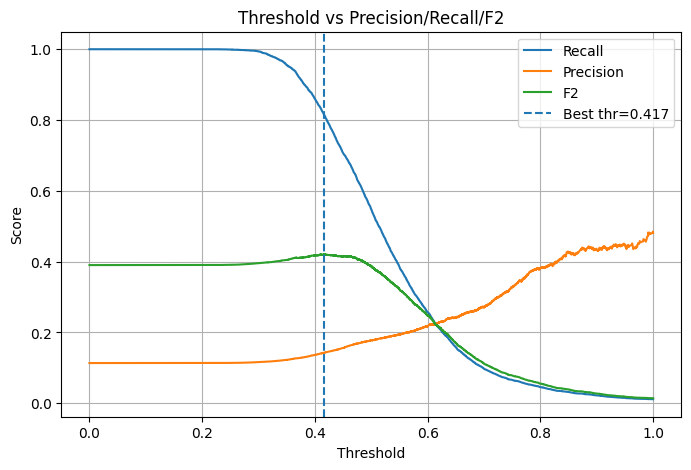

In [ ]:
# decide threshold on validation set



info = best_threshold_by_fbeta(y_validate, sgd_scores, beta=2.0)
best_thresh = info['threshold']
y_pred_custom = (sgd_scores >= best_thresh).astype(int)

print(f"Best threshold (F2): {best_thresh:.4f}")
print(f"Precision: {info['precision']:.3f}  Recall: {info['recall']:.3f}  F2: {info['fbeta']:.3f}")

plot_scoring(info['curve'])

In [ ]:
# use the threshold for predicitons on the held out test set

from shared_util.metrics.printing import print_metrics

sgd_scores_test = get_scores(sgd_est, X_test)

y_pred_custom_test = (sgd_scores_test >= best_thresh).astype(int)

print_metrics(
    y_true=y_test,
    y_pred=y_pred_custom_test,
    y_proba=sgd_scores_test,
    metrics_db_id=METRICS_DB_ID,
    metrics_notes=METRIC_NOTES,
    log=LOG,
    model='sgd_test_f2_weighted',
    hyperparam_notes='tuned best ROC',
    pipeline_notes='under_sample'

)

ROC_AUC:     0.6618466602570225
Accuracy:      0.42551150895140666
F1 score:      0.24460091429772476
Precision:     0.14374382411067194
Recall:        0.8198309263825291

Confusion matrix:

TN: 16641, FP: 27729, FN: 1023, TP: 4655

Classification report:
               precision    recall  f1-score   support

           0       0.94      0.38      0.54     44370
           1       0.14      0.82      0.24      5678

    accuracy                           0.43     50048
   macro avg       0.54      0.60      0.39     50048
weighted avg       0.85      0.43      0.50     50048

logged row: (0, sgd_test_f2_weighted)


In [ ]:
# SVM
from sklearn.svm import SVC
from shared_util.baseline import get_baseline_score

roc_auc = get_baseline_score(
    SVC(random_state=42),
    RandomUnderSampler(random_state=42),
    X_train,
    y_train,
    scaler=StandardScaler()
)

if LOG:
    metrics_db.log_metric(
        metric_id=METRICS_DB_ID,
        model='svc_base_undsampl',
        pipeline_notes='under_sample',
        notes=METRIC_NOTES,
        roc_auc=roc_auc
    )






roc_auc_score score per fold:  [0.60522957 0.61182892 0.61342205 0.60414837 0.60889415 0.60595621
 0.60999998 0.61167097 0.61039046 0.58971512]
mean roc_auc_score score:  0.607125582042585
logged row: (0, svc_base_undsampl)


In [ ]:
# running smote did not get a result after 6 hours so leaving it out for now
# roc_auc = get_baseline_score(
#     SVC(random_state=42),
#     SMOTE(random_state=42),
#     X_train,
#     y_train,
#     scaler=StandardScaler()
# )

# if LOG:
#     metrics_db.log_metric(
#         metric_id=METRICS_DB_ID,
#         model='svc_base_smote',
#         pipeline_notes='SMOTE',
#         notes=METRIC_NOTES,
#         roc_auc=roc_auc
#     )


## Hyperparameter sweep for SVM

In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import RandomizedSearchCV
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingRandomSearchCV #type: ignore
from scipy.stats import loguniform



def make_base_svc():
    return Pipeline([
        ('sampler', RandomUnderSampler(random_state=42)),
        ('scaler', StandardScaler()),
        ('model', SVC(random_state=42, cache_size=16384, probability=True))
    ])
# limited param search due to computation time
svc_param_grid = {
    "model__kernel": ["rbf", "poly"],
    "model__C": loguniform(1e-3, 1e3),
    "model__gamma": [0.001, 0.01, 0.1, 1],
    "model__class_weight": ["balanced"],
    "model__shrinking": [False],
}

# reduced to 5 folds again for computation time

cv_svc = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
    )

rs_hsvc = HalvingRandomSearchCV(
    estimator=make_base_svc(),
    param_distributions=svc_param_grid,
   # n_iter=50,  
    scoring='roc_auc',
    cv=make_cv(),
    n_jobs=-1,
    random_state=42,
    refit=True,
    verbose=1
)

rs_svc = RandomizedSearchCV(
    estimator=make_base_svc(),
    param_distributions=svc_param_grid,
    n_iter=50,  
    scoring='roc_auc',
    cv=cv_svc,
    n_jobs=-1,
    random_state=42,
    refit=True,
    verbose=2  # Show progress since SVC is slow
)

rs_hsvc.fit(X_train, y_train)

print(f'Best ROC_AUC (cv): {rs_hsvc.best_score_}')
print(f'Best params: {rs_hsvc.best_params_}')

res_df = pd.DataFrame(rs_hsvc.cv_results_).sort_values('rank_test_score').reset_index(drop=True)
res_df[['rank_test_score','mean_test_score','std_test_score','params']].head(10)

n_iterations: 7
n_required_iterations: 7
n_possible_iterations: 7
min_resources_: 40
max_resources_: 80076
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 2001
n_resources: 40
Fitting 10 folds for each of 2001 candidates, totalling 20010 fits
----------
iter: 1
n_candidates: 667
n_resources: 120
Fitting 10 folds for each of 667 candidates, totalling 6670 fits
----------
iter: 2
n_candidates: 223
n_resources: 360
Fitting 10 folds for each of 223 candidates, totalling 2230 fits
----------
iter: 3
n_candidates: 75
n_resources: 1080
Fitting 10 folds for each of 75 candidates, totalling 750 fits
----------
iter: 4
n_candidates: 25
n_resources: 3240
Fitting 10 folds for each of 25 candidates, totalling 250 fits
----------
iter: 5
n_candidates: 9
n_resources: 9720
Fitting 10 folds for each of 9 candidates, totalling 90 fits
----------
iter: 6
n_candidates: 3
n_resources: 29160
Fitting 10 folds for each of 3 candidates, totalling 30 fits
Best ROC_AUC (cv): 0.6455887115

,rank_test_score,mean_test_score,std_test_score,params
0,1,0.645589,0.014444,"{'model__C': 5.535488438866432, 'model__class_..."
1,2,0.644759,0.014817,"{'model__C': 1.628773852289148, 'model__class_..."
2,3,0.638409,0.015161,"{'model__C': 25.72919881245235, 'model__class_..."
3,4,0.630332,0.026484,"{'model__C': 1.628773852289148, 'model__class_..."
4,5,0.628677,0.023097,"{'model__C': 5.535488438866432, 'model__class_..."
5,6,0.627012,0.018067,"{'model__C': 25.72919881245235, 'model__class_..."
6,7,0.626926,0.032815,"{'model__C': 0.1356149012666165, 'model__class..."
7,8,0.626752,0.032852,"{'model__C': 0.0022993460739742675, 'model__cl..."
8,8,0.626752,0.032852,"{'model__C': 0.004156647661004857, 'model__cla..."
9,8,0.626752,0.032852,"{'model__C': 0.022905428113532533, 'model__cla..."


In [ ]:
# The above code block generates best hyperparams for our SVC model:

# Best ROC_AUC (cv): 0.6455887115233095
# Best params: {
#       'model__C': np.float64(5.535488438866432), 
#       'model__class_weight': 'balanced', 
#       'model__gamma': 0.001, 
#       'model__kernel': 'rbf', 
#       'model__shrinking': False
#      }

In [ ]:
# predict on validate set before threshold changes
svm_est = rs_hsvc.best_estimator_
svm_scores = get_scores(svm_est, X_validate)

y_pred = svm_est.predict(X_validate) #type: ignore

print_metrics(
              y_true=y_test, 
              y_pred=y_pred, 
              y_proba=svm_scores,
              metrics_db_id=METRICS_DB_ID,
              metrics_notes=METRIC_NOTES,
              model='svc_validate',
              hyperparam_notes='tuned best roc, uses HalvingRandomSearchCV',
              pipeline_notes='under_sample',
              log=LOG
)



Best threshold (F2): -0.5614
Precision: 0.160  Recall: 0.752  F2: 0.431


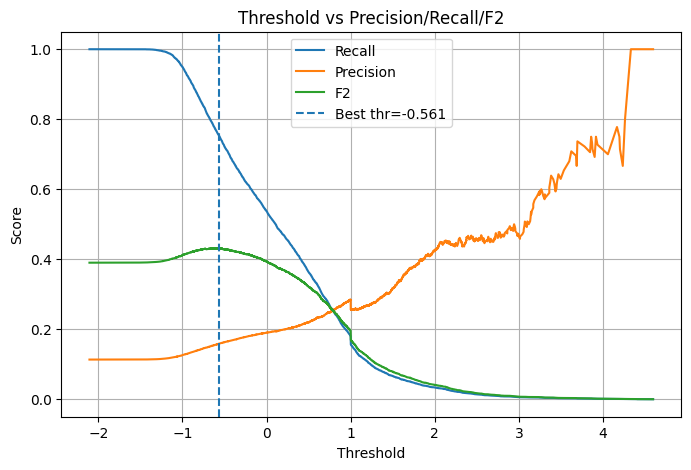

In [ ]:
# threshold sweep using validation set
from shared_util.metrics.scoring import get_scores, best_threshold_by_fbeta, plot_scoring



info = best_threshold_by_fbeta(y_validate, svm_scores, beta=2.0)

best_thresh = info["threshold"]
y_pred_custom = (svm_scores >= best_thresh).astype(int)

print(f"Best threshold (F2): {best_thresh:.4f}")
print(f"Precision: {info['precision']:.3f}  Recall: {info['recall']:.3f}  F2: {info['fbeta']:.3f}")

plot_scoring(info['curve'])

In [ ]:
# held out test prediction using calculated threshold

# this inference took ~25 seconds, considering other models took <1 second, thats a significant downside to SVC

svm_scores_test = get_scores(svm_est, X_test)

y_pred_test_svm = (svm_scores_test >= best_thresh).astype(int)


In [ ]:
from shared_util.metrics.printing import print_metrics

print ('Held out test metrics for (Support Vector Classifier)')

print_metrics(
              y_true=y_test, 
              y_pred=y_pred_test_svm, 
              y_proba=svm_scores_test,
              metrics_db_id=METRICS_DB_ID,
              metrics_notes=METRIC_NOTES,
              model='svc_test_f2_weighted',
              hyperparam_notes='tuned best roc, uses HalvingRandomSearchCV',
              pipeline_notes='under_sample',
              log=LOG
              )

Held out test metrics for (Support Vector Classifier)
ROC_AUC:     0.6755070140512833
Accuracy:      0.517423273657289
F1 score:      0.26090948038435646
Precision:     0.15788888888888888
Recall:        0.750792532581895

Confusion matrix:

TN: 21633, FP: 22737, FN: 1415, TP: 4263

Classification report:
               precision    recall  f1-score   support

           0       0.94      0.49      0.64     44370
           1       0.16      0.75      0.26      5678

    accuracy                           0.52     50048
   macro avg       0.55      0.62      0.45     50048
weighted avg       0.85      0.52      0.60     50048

logged row: (0, svc_test_f2_weighted)


Both SVM and the SGD classifier both achieved above expected results compared to previous literature, which showed linear models performing, generally, with a ROC_AUC below 0.600.

